In [1]:
import pandas as pd
import numpy as np

TRADING_DAYS = 252
RISK_FREE_RATE = 0.02

prices = pd.read_csv(
    "../data/raw/stock_prices_20260102.csv",
    index_col=0,
    parse_dates=True
)

returns = prices.pct_change().dropna()


In [2]:
mu = returns.mean() * TRADING_DAYS
cov = returns.cov() * TRADING_DAYS

In [3]:
def portfolio_performance(weights, mu, cov):
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe = (port_return - RISK_FREE_RATE) / port_vol
    return port_return, port_vol, sharpe


In [4]:
n_assets = len(mu)
n_portfolios = 20000

results = np.zeros((n_portfolios, 3))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= weights.sum()

    ret, vol, sharpe = portfolio_performance(weights, mu, cov)

    results[i] = [ret, vol, sharpe]
    weights_record.append(weights)

results_df = pd.DataFrame(
    results, columns=["return", "volatility", "sharpe"]
)


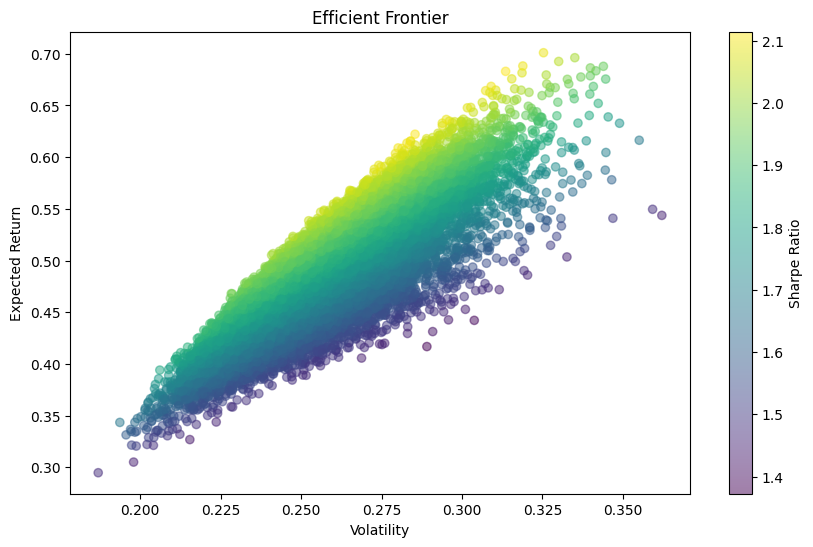

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["volatility"],
    results_df["return"],
    c=results_df["sharpe"],
    cmap="viridis",
    alpha=0.5
)
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.show()


In [6]:
max_sharpe_idx = results_df["sharpe"].idxmax()
optimal_weights = weights_record[max_sharpe_idx]

optimal_portfolio = pd.Series(
    optimal_weights,
    index=mu.index,
    name="weight"
)

optimal_portfolio


AAPL     0.032441
AMZN     0.034937
GOOGL    0.249614
META     0.161326
MSFT     0.045020
NVDA     0.379114
SPY      0.022785
TSLA     0.074763
Name: weight, dtype: float64

## Interpretation 

- 어떤 종목 비중이 높은가
- 분산 효과가 나타났는가
- 단일 종목 투자 대비 변동성 감소 여부

In [7]:
equal_weights = np.repeat(1 / n_assets, n_assets)

ew_ret, ew_vol, ew_sharpe = portfolio_performance(
    equal_weights, mu, cov
)


In [8]:
summary = pd.DataFrame({
    "Portfolio": ["Optimal (Max Sharpe)", "Equal Weight"],
    "Return": [results_df.loc[max_sharpe_idx, "return"], ew_ret],
    "Volatility": [results_df.loc[max_sharpe_idx, "volatility"], ew_vol],
    "Sharpe": [results_df.loc[max_sharpe_idx, "sharpe"], ew_sharpe]
})

summary


,Portfolio,Return,Volatility,Sharpe
0,Optimal (Max Sharpe),0.682964,0.313569,2.114254
1,Equal Weight,0.489822,0.253159,1.855837
